# Data Unification v3 - FIXED
## Comprehensive Fixes for All Imbalance Issues

**Fixes:**
- ✅ Proper compound skill parsing ("Python, SQL" → ["Python", "SQL"])
- ✅ More aggressive skill rebalancing (cap at 500, remove < 50)
- ✅ Fixed career-to-category mapping (reduce "Other" to < 10%)
- ✅ Balanced simulation categories (10-20 per category)
- ✅ No user duplication (skill-level rebalancing only)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from collections import Counter
import json
import random
from sklearn.preprocessing import LabelEncoder
import re
from copy import deepcopy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)

data_dir = Path('/workspace/data/raw')
output_dir = Path('/workspace/data/processed')
viz_dir = Path('/workspace/data/visualizations')
output_dir.mkdir(parents=True, exist_ok=True)
viz_dir.mkdir(parents=True, exist_ok=True)

random.seed(42)
np.random.seed(42)

print("✓ Setup complete")

✓ Setup complete


---
## Step 1: Load Datasets

In [2]:
df_ai = pd.read_csv(data_dir / 'ai_career.csv')
df_career = pd.read_csv(data_dir / 'career_paths.csv')
df_skill = pd.read_csv(data_dir / 'skill_career.csv')

print(f"AI Career: {df_ai.shape}")
print(f"Career Paths: {df_career.shape}")
print(f"Skill & Career: {df_skill.shape}")
print(f"Total: {len(df_ai) + len(df_career) + len(df_skill):,}")

AI Career: (200, 8)
Career Paths: (5000, 6)
Skill & Career: (3999, 21)
Total: 9,199


---
## Step 2: IMPROVED Career Categories (Fix "Other" Problem)

In [3]:
# EXPANDED career categories with more comprehensive mapping
CAREER_CATEGORIES = {
    'STEM': [
        'software engineer', 'ml engineer', 'data scientist', 'research scientist',
        'ai engineer', 'devops engineer', 'cloud architect', 'backend developer',
        'frontend developer', 'full stack developer', 'data analyst', 'data engineer',
        'astronomer', 'geologist', 'research analyst', 'software developer',
        'systems engineer', 'database administrator', 'web developer', 'mobile developer',
        'qa engineer', 'test engineer', 'network engineer', 'security engineer',
        'blockchain developer', 'game developer', 'embedded engineer', 'technical architect',
        'solutions architect', 'platform engineer', 'site reliability engineer', 'mathematician',
        'physicist', 'chemist', 'biologist', 'engineer', 'developer', 'programmer',
        'analyst', 'scientist', 'researcher', 'technician', 'architect'
    ],
    'Business': [
        'marketing executive', 'product manager', 'business analyst', 'project manager',
        'consultant', 'marketing', 'logistics manager', 'operations manager',
        'supply chain manager', 'business development', 'sales manager', 'hr manager',
        'account manager', 'brand manager', 'digital marketing', 'content strategist',
        'business consultant', 'strategy consultant', 'management consultant',
        'product owner', 'scrum master', 'agile coach', 'operations director',
        'chief operating officer', 'coo', 'general manager', 'business manager',
        'marketing manager', 'sales executive', 'business executive', 'operations executive',
        'relationship manager', 'client manager', 'customer success manager'
    ],
    'Finance': [
        'financial analyst', 'accountant', 'investment banker', 'clerk', 'auditor',
        'tax consultant', 'finance manager', 'risk analyst', 'portfolio manager',
        'financial advisor', 'wealth manager', 'credit analyst', 'budget analyst',
        'treasury analyst', 'compliance officer', 'financial controller', 'cfo',
        'chief financial officer', 'financial planner', 'insurance agent',
        'actuary', 'economist', 'quantitative analyst', 'trader', 'investment analyst',
        'equity analyst', 'research associate', 'financial consultant'
    ],
    'Health': [
        'doctor', 'nurse', 'psychologist', 'therapist', 'healthcare administrator',
        'medical researcher', 'clinical psychologist', 'pharmacist', 'dentist',
        'physician', 'surgeon', 'psychiatrist', 'medical assistant', 'paramedic',
        'physical therapist', 'occupational therapist', 'nutritionist', 'dietitian',
        'public health', 'healthcare', 'medical', 'clinical', 'patient care'
    ],
    'Design': [
        'ux designer', 'ui designer', 'graphic designer', 'product designer',
        'creative director', 'web designer', 'interior designer', 'fashion designer',
        'industrial designer', 'motion designer', 'visual designer', '3d designer',
        'illustrator', 'art director', 'design lead', 'interaction designer',
        'user researcher', 'brand designer', 'designer', 'artist', 'creative'
    ],
    'Legal': [
        'lawyer', 'legal advisor', 'paralegal', 'attorney', 'legal counsel',
        'corporate lawyer', 'litigation lawyer', 'patent attorney', 'legal consultant',
        'judge', 'magistrate', 'legal analyst', 'compliance lawyer', 'contract manager',
        'legal manager', 'legal', 'law'
    ],
    'Education': [
        'teacher', 'professor', 'trainer', 'instructional designer', 'education coordinator',
        'lecturer', 'tutor', 'teaching assistant', 'curriculum developer', 'principal',
        'dean', 'academic advisor', 'school counselor', 'education administrator',
        'learning specialist', 'educator', 'instructor', 'academic', 'faculty'
    ]
}

# Flatten for faster lookup
career_to_category = {}
for category, careers in CAREER_CATEGORIES.items():
    for career in careers:
        career_to_category[career.lower()] = category

def map_career_to_category(career_name):
    """Improved mapping with fuzzy matching"""
    if pd.isna(career_name):
        return 'Other'
    
    career_clean = str(career_name).strip().lower()
    
    # Exact match
    if career_clean in career_to_category:
        return career_to_category[career_clean]
    
    # Fuzzy match (check if any keyword is in the career name)
    for keyword, category in career_to_category.items():
        if keyword in career_clean:
            return category
    
    return 'Other'

CATEGORY_TO_INDUSTRY = {
    'STEM': 'Technology',
    'Business': 'Business & Management',
    'Finance': 'Finance & Banking',
    'Health': 'Healthcare',
    'Design': 'Creative & Design',
    'Legal': 'Legal Services',
    'Education': 'Education'
}

print(f"✓ Career categories defined: {len(CAREER_CATEGORIES)}")
print(f"✓ Total career keywords: {len(career_to_category)}")

✓ Career categories defined: 7
✓ Total career keywords: 185


---
## Step 3: Skill Inference Rules

In [4]:
# Career-to-skills rules (same as before)
CAREER_SKILL_RULES = {
    # ========================================
    # STEM CAREERS (14 total skills)
    # ========================================
    'Software Engineer': {
        'always': ['Python', 'Git'],
        'common': ['JavaScript', 'React', 'Node.js', 'SQL', 'Docker'],
        'rare': ['AWS', 'Kubernetes', 'MongoDB']
    },
    'Data Scientist': {
        'always': ['Python', 'Machine Learning', 'Data Analysis'],
        'common': ['SQL', 'TensorFlow', 'Statistics', 'R'],
        'rare': ['AWS', 'Docker']
    },
    'Machine Learning Engineer': {
        'always': ['Python', 'Machine Learning', 'TensorFlow'],
        'common': ['Deep Learning', 'Data Analysis', 'Git'],
        'rare': ['Docker', 'Kubernetes']
    },
    'ML Engineer': {
        'always': ['Python', 'Machine Learning', 'TensorFlow'],
        'common': ['Deep Learning', 'Data Analysis', 'Git'],
        'rare': ['Docker', 'Kubernetes']
    },
    'Data Analyst': {
        'always': ['Excel', 'Data Analysis', 'SQL'],
        'common': ['Python', 'Tableau', 'Statistics'],
        'rare': ['R', 'PowerBI']
    },
    'Full Stack Developer': {
        'always': ['JavaScript', 'React', 'Node.js'],
        'common': ['Python', 'SQL', 'Git', 'MongoDB'],
        'rare': ['Docker', 'AWS']
    },
    'Backend Developer': {
        'always': ['Python', 'SQL', 'Node.js'],
        'common': ['MongoDB', 'Git', 'Docker'],
        'rare': ['Kubernetes', 'AWS']
    },
    'Frontend Developer': {
        'always': ['JavaScript', 'React', 'HTML/CSS'],
        'common': ['Git', 'TypeScript', 'Figma'],
        'rare': ['Node.js', 'Docker']
    },
    'DevOps Engineer': {
        'always': ['Docker', 'Kubernetes', 'Git'],
        'common': ['AWS', 'Azure', 'Python', 'Linux'],
        'rare': ['Terraform', 'Jenkins']
    },
    'Software Developer': {
        'always': ['Python', 'Git'],
        'common': ['JavaScript', 'SQL', 'Docker'],
        'rare': ['React', 'Node.js']
    },
    'AI Engineer': {
        'always': ['Python', 'Machine Learning', 'Deep Learning'],
        'common': ['TensorFlow', 'Git', 'Data Analysis'],
        'rare': ['AWS', 'Docker']
    },
    'Research Scientist': {
        'always': ['Python', 'Research', 'Statistics'],
        'common': ['Machine Learning', 'Data Analysis'],
        'rare': ['R', 'TensorFlow']
    },
    'Research Analyst': {
        'always': ['Research', 'Data Analysis', 'Excel'],
        'common': ['Statistics', 'SQL', 'Python'],
        'rare': ['Tableau', 'R']
    },
    
    # ========================================
    # BUSINESS CAREERS (17 total skills)
    # ========================================
    'Marketing Manager': {
        'always': ['Marketing', 'Strategic Planning'],
        'common': ['Google Analytics', 'SEO', 'Content Strategy', 'Social Media'],
        'rare': ['Email Marketing', 'Brand Management']
    },
    'Marketing Executive': {
        'always': ['Marketing', 'Strategic Planning'],
        'common': ['Google Analytics', 'SEO', 'Content Strategy', 'Social Media'],
        'rare': ['Email Marketing', 'Brand Management']
    },
    'Digital Marketer': {
        'always': ['Marketing', 'Social Media'],
        'common': ['SEO', 'Google Analytics', 'Content Creation', 'Email Marketing'],
        'rare': ['PPC', 'Copywriting']
    },
    'Project Manager': {
        'always': ['Project Management', 'Agile'],
        'common': ['Scrum', 'Excel', 'Jira', 'Leadership'],
        'rare': ['Risk Management', 'Budgeting']
    },
    'Product Manager': {
        'always': ['Product Management', 'Agile'],
        'common': ['Market Research', 'Data Analysis', 'Strategic Planning'],
        'rare': ['SQL', 'Wireframing']
    },
    'Business Analyst': {
        'always': ['Business Analysis', 'Excel'],
        'common': ['SQL', 'Data Analysis', 'Requirements Gathering'],
        'rare': ['Python', 'Tableau']
    },
    'Consultant': {
        'always': ['Strategic Planning', 'Business Analysis'],
        'common': ['Excel', 'PowerPoint', 'Market Research'],
        'rare': ['Data Analysis', 'Financial Modeling']
    },
    'Operations Manager': {
        'always': ['Operations Management', 'Process Optimization'],
        'common': ['Excel', 'Project Management', 'Leadership'],
        'rare': ['Six Sigma', 'Lean Manufacturing']
    },
    'Supply Chain Manager': {
        'always': ['Supply Chain Management', 'Operations Management'],
        'common': ['Excel', 'SAP', 'Process Optimization'],
        'rare': ['Data Analysis', 'Forecasting']
    },
    'Sales Manager': {
        'always': ['Sales', 'CRM'],
        'common': ['Salesforce', 'Negotiation', 'Leadership'],
        'rare': ['Market Research', 'Excel']
    },
    'Account Manager': {
        'always': ['CRM', 'Client Management'],
        'common': ['Salesforce', 'Negotiation', 'Excel'],
        'rare': ['Data Analysis', 'Marketing']
    },
    'HR Manager': {
        'always': ['HR Management', 'Talent Acquisition'],
        'common': ['Employee Relations', 'Performance Management', 'Excel'],
        'rare': ['HR Analytics', 'Payroll']
    },
    
    # ========================================
    # FINANCE CAREERS (15 total skills)
    # ========================================
    'Financial Analyst': {
        'always': ['Financial Analysis', 'Excel', 'Financial Modeling'],
        'common': ['Valuation', 'DCF Analysis', 'Accounting', 'Forecasting'],
        'rare': ['Bloomberg Terminal', 'SQL']
    },
    'Accountant': {
        'always': ['Accounting', 'Excel'],
        'common': ['QuickBooks', 'Tax Planning', 'Auditing', 'Financial Analysis'],
        'rare': ['SAP', 'Budgeting']
    },
    'Investment Banker': {
        'always': ['Financial Modeling', 'Valuation', 'DCF Analysis'],
        'common': ['Excel', 'Financial Analysis', 'Bloomberg Terminal'],
        'rare': ['PowerPoint', 'M&A']
    },
    'Risk Analyst': {
        'always': ['Risk Management', 'Financial Analysis'],
        'common': ['Excel', 'Statistics', 'Data Analysis'],
        'rare': ['Python', 'R']
    },
    'Portfolio Manager': {
        'always': ['Portfolio Management', 'Financial Analysis'],
        'common': ['Risk Management', 'Excel', 'Bloomberg Terminal'],
        'rare': ['Python', 'Quantitative Analysis']
    },
    'Auditor': {
        'always': ['Auditing', 'Accounting'],
        'common': ['Excel', 'Financial Analysis', 'Compliance'],
        'rare': ['SAP', 'Risk Management']
    },
    'Tax Consultant': {
        'always': ['Tax Planning', 'Accounting'],
        'common': ['Excel', 'Tax Law', 'Compliance'],
        'rare': ['QuickBooks', 'Financial Analysis']
    },
    'Finance Manager': {
        'always': ['Financial Management', 'Budgeting'],
        'common': ['Financial Analysis', 'Excel', 'Forecasting'],
        'rare': ['SAP', 'Risk Management']
    },
    
    # ========================================
    # HEALTH CAREERS (10 total skills)
    # ========================================
    'Doctor': {
        'always': ['Medical Knowledge', 'Clinical Assessment', 'Diagnostic Skills'],
        'common': ['Patient Care', 'Pharmacology', 'Medical Terminology'],
        'rare': ['EMR Systems', 'Patient Education']
    },
    'Nurse': {
        'always': ['Patient Care', 'Medical Knowledge'],
        'common': ['Clinical Assessment', 'Medical Terminology', 'EMR Systems'],
        'rare': ['Pharmacology', 'Emergency Response']
    },
    'Psychologist': {
        'always': ['Counseling', 'Clinical Assessment'],
        'common': ['Patient Care', 'Patient Education', 'Diagnostic Skills'],
        'rare': ['Research', 'Statistics']
    },
    'Therapist': {
        'always': ['Counseling', 'Patient Care'],
        'common': ['Clinical Assessment', 'Patient Education'],
        'rare': ['EMR Systems', 'Medical Knowledge']
    },
    'Healthcare Administrator': {
        'always': ['Healthcare Management', 'Compliance'],
        'common': ['Budgeting', 'Excel', 'EMR Systems'],
        'rare': ['Data Analysis', 'Project Management']
    },
    'Medical Researcher': {
        'always': ['Research', 'Medical Knowledge'],
        'common': ['Statistics', 'Clinical Trials', 'Data Analysis'],
        'rare': ['Python', 'R']
    },
    
    # ========================================
    # DESIGN CAREERS (10 total skills)
    # ========================================
    'UX Designer': {
        'always': ['UX Research', 'Figma', 'Wireframing'],
        'common': ['Prototyping', 'User Research', 'UI Design'],
        'rare': ['Visual Design', 'Adobe Creative Suite']
    },
    'UI Designer': {
        'always': ['UI Design', 'Figma'],
        'common': ['Visual Design', 'Prototyping', 'Adobe Creative Suite'],
        'rare': ['UX Research', 'HTML/CSS']
    },
    'Graphic Designer': {
        'always': ['Visual Design', 'Adobe Creative Suite'],
        'common': ['Photoshop', 'Illustrator', 'Branding'],
        'rare': ['Figma', 'UI Design']
    },
    'Product Designer': {
        'always': ['Product Design', 'Figma', 'Prototyping'],
        'common': ['UX Research', 'UI Design', 'Wireframing'],
        'rare': ['User Research', 'Visual Design']
    },
    'Web Designer': {
        'always': ['Web Design', 'HTML/CSS', 'Visual Design'],
        'common': ['JavaScript', 'Figma', 'UI Design'],
        'rare': ['React', 'UX Research']
    },
    'Creative Director': {
        'always': ['Creative Direction', 'Visual Design', 'Brand Management'],
        'common': ['Adobe Creative Suite', 'Strategic Planning', 'Leadership'],
        'rare': ['Figma', 'Marketing']
    },
    
    # ========================================
    # EDUCATION CAREERS (9 total skills)
    # ========================================
    'Teacher': {
        'always': ['Pedagogy', 'Lesson Planning', 'Classroom Management'],
        'common': ['Curriculum Development', 'Assessment Design', 'Student Engagement'],
        'rare': ['Educational Technology', 'Differentiation']
    },
    'Professor': {
        'always': ['Pedagogy', 'Research'],
        'common': ['Curriculum Development', 'Academic Writing'],
        'rare': ['Grant Writing', 'Statistics']
    },
    'Trainer': {
        'always': ['Training', 'Curriculum Development'],
        'common': ['Pedagogy', 'Assessment Design', 'Facilitation'],
        'rare': ['Educational Technology', 'LMS']
    },
    'Instructional Designer': {
        'always': ['Instructional Design', 'Curriculum Development'],
        'common': ['Educational Technology', 'LMS', 'Assessment Design'],
        'rare': ['Pedagogy', 'Video Production']
    },
    'Education Coordinator': {
        'always': ['Program Coordination', 'Curriculum Development'],
        'common': ['Pedagogy', 'Student Engagement', 'Assessment Design'],
        'rare': ['Educational Technology', 'Budget Management']
    },
    
    # ========================================
    # LEGAL CAREERS (7 total skills)
    # ========================================
    'Lawyer': {
        'always': ['Legal Research', 'Legal Writing', 'Case Analysis'],
        'common': ['Contract Review', 'Litigation', 'Compliance'],
        'rare': ['Negotiation', 'Intellectual Property']
    },
    'Legal Advisor': {
        'always': ['Legal Research', 'Legal Writing'],
        'common': ['Contract Review', 'Compliance', 'Advisory'],
        'rare': ['Negotiation', 'Risk Management']
    },
    'Paralegal': {
        'always': ['Legal Research', 'Document Preparation'],
        'common': ['Case Analysis', 'Contract Review'],
        'rare': ['Litigation Support', 'Legal Writing']
    },
    'Attorney': {
        'always': ['Legal Research', 'Legal Writing', 'Litigation'],
        'common': ['Case Analysis', 'Contract Review', 'Negotiation'],
        'rare': ['Trial Advocacy', 'Compliance']
    },
    
    # ========================================
    # DEFAULT (for any career not listed above)
    # ========================================
    'DEFAULT': {
        'always': ['Research'],
        'common': ['Excel'],
        'rare': []
    }
}

print(f"✓ Expanded career skill rules loaded ({len(CAREER_SKILL_RULES)} career mappings)")
print(f"  This will generate ~80-90 unique skills across all categories")

def infer_skills_for_career(career_name, existing_skills=None):
    if existing_skills is None:
        existing_skills = []
    
    skills = set(existing_skills)
    rules = CAREER_SKILL_RULES.get(career_name, CAREER_SKILL_RULES['DEFAULT'])
    
    skills.update(rules['always'])
    for skill in rules['common']:
        if random.random() < 0.6:
            skills.add(skill)
    for skill in rules['rare']:
        if random.random() < 0.3:
            skills.add(skill)
    
    return list(skills)

print(f"✓ Skill inference rules loaded")

✓ Expanded career skill rules loaded (55 career mappings)
  This will generate ~80-90 unique skills across all categories
✓ Skill inference rules loaded


---
## Step 4: Learning Style Profiles

In [5]:
# Learning style profiles (same as before)
CATEGORY_LEARNING_PROFILES = {
    'STEM': {'analytical': (70, 95), 'creative': (30, 50), 'social': (30, 60), 'linguistic': (40, 60), 'hands_on': (60, 90)},
    'Business': {'analytical': (50, 75), 'creative': (45, 70), 'social': (65, 90), 'linguistic': (70, 90), 'hands_on': (40, 65)},
    'Finance': {'analytical': (75, 95), 'creative': (25, 45), 'social': (40, 60), 'linguistic': (50, 70), 'hands_on': (50, 70)},
    'Health': {'analytical': (55, 75), 'creative': (40, 60), 'social': (75, 95), 'linguistic': (65, 85), 'hands_on': (60, 85)},
    'Design': {'analytical': (35, 60), 'creative': (80, 98), 'social': (50, 75), 'linguistic': (55, 75), 'hands_on': (65, 85)},
    'Legal': {'analytical': (70, 90), 'creative': (30, 50), 'social': (55, 75), 'linguistic': (80, 95), 'hands_on': (30, 50)},
    'Education': {'analytical': (45, 65), 'creative': (55, 75), 'social': (70, 90), 'linguistic': (75, 92), 'hands_on': (50, 70)},
    'Other': {'analytical': (40, 60), 'creative': (40, 60), 'social': (40, 60), 'linguistic': (40, 60), 'hands_on': (40, 60)}
}

def infer_learning_scores(category, base_scores=None):
    profile = CATEGORY_LEARNING_PROFILES.get(category, CATEGORY_LEARNING_PROFILES['Other'])
    scores = {}
    for dimension, (min_val, max_val) in profile.items():
        if base_scores and dimension in base_scores:
            base = base_scores[dimension]
            noise = np.random.randint(-10, 11)
            score = np.clip(base + noise, min_val, max_val)
        else:
            score = np.random.randint(min_val, max_val + 1)
        scores[dimension] = score
    return scores

print("✓ Learning profiles loaded")

✓ Learning profiles loaded


---
## Step 5: Transform Datasets with PROPER Skill Parsing

In [6]:
def clean_and_split_skills(skill_text):
    """Parse skills properly, handling comma-separated values"""
    if pd.isna(skill_text) or skill_text == '':
        return []
    
    # Split by semicolon or comma
    if ';' in str(skill_text):
        skills = str(skill_text).split(';')
    elif ',' in str(skill_text):
        skills = str(skill_text).split(',')
    else:
        skills = [str(skill_text)]
    
    # Clean each skill
    cleaned = []
    for skill in skills:
        s = skill.strip()
        if s and len(s) > 1:  # Avoid single chars
            cleaned.append(s)
    
    return cleaned

# Transform AI Career dataset
ai_profiles = []
for idx, row in df_ai.iterrows():
    skills_clean = clean_and_split_skills(row['Skills'])
    career = row['Recommended_Career']
    category = map_career_to_category(career)
    all_skills = infer_skills_for_career(career, existing_skills=skills_clean)
    
    education_map = {"Bachelor's": "Bachelor's", "Master's": "Master's", "PhD": "PhD"}
    education = education_map.get(row['Education'], "Bachelor's")
    
    field_map = {'STEM': 'Computer Science', 'Business': 'Business', 'Finance': 'Finance',
                 'Health': 'Health Sciences', 'Design': 'Design', 'Legal': 'Law',
                 'Education': 'Education', 'Other': 'General Studies'}
    field = field_map.get(category, 'General Studies')
    
    learning_scores = infer_learning_scores(category)
    
    ai_profiles.append({
        'user_id': f'ai_{idx}',
        'source_dataset': 'ai_career',
        'skills': all_skills,
        'education_level': education,
        'field_of_study': field,
        'analytical_score': learning_scores['analytical'],
        'creative_score': learning_scores['creative'],
        'social_score': learning_scores['social'],
        'linguistic_score': learning_scores['linguistic'],
        'hands_on_score': learning_scores['hands_on'],
        'recommended_career': career,
        'recommended_category': category,
        'base_engagement_score': row['Recommendation_Score']
    })

print(f"✓ AI Career: {len(ai_profiles)} profiles")

# Transform Career Paths dataset
cp_profiles = []
for idx, row in df_career.iterrows():
    skills_clean = clean_and_split_skills(row['Skills'])
    career = row['Recommended Career']
    category = map_career_to_category(career)
    all_skills = infer_skills_for_career(career, existing_skills=skills_clean)
    
    education_map = {'Matric': 'High School', 'Intermediate': 'High School',
                    "Bachelor's": "Bachelor's", "Master's": "Master's", "PhD": "PhD"}
    education = education_map.get(row['Education Level'], "Bachelor's")
    field = row['Specialization']
    learning_scores = infer_learning_scores(category)
    engagement_score = row['CGPA/Percentage'] / 100.0
    
    cp_profiles.append({
        'user_id': f'cp_{idx}',
        'source_dataset': 'career_paths',
        'skills': all_skills,
        'education_level': education,
        'field_of_study': field,
        'analytical_score': learning_scores['analytical'],
        'creative_score': learning_scores['creative'],
        'social_score': learning_scores['social'],
        'linguistic_score': learning_scores['linguistic'],
        'hands_on_score': learning_scores['hands_on'],
        'recommended_career': career,
        'recommended_category': category,
        'base_engagement_score': engagement_score
    })

print(f"✓ Career Paths: {len(cp_profiles)} profiles")

# Transform Skill & Career dataset
sc_profiles = []
df_skill_clean = df_skill.dropna(subset=['Job profession'])

for idx, row in df_skill_clean.iterrows():
    career = row['Job profession']
    category = map_career_to_category(career)
    all_skills = infer_skills_for_career(career, existing_skills=[])
    
    course = row['Course'] if pd.notna(row['Course']) else 3
    if course <= 2:
        education = 'High School'
    elif course <= 3:
        education = "Bachelor's"
    elif course <= 4:
        education = "Master's"
    else:
        education = "PhD"
    
    field_map = {'STEM': 'Computer Science', 'Business': 'Business', 'Finance': 'Finance',
                 'Health': 'Health Sciences', 'Design': 'Design', 'Legal': 'Law',
                 'Education': 'Education', 'Other': 'General Studies'}
    field = field_map.get(category, 'General Studies')
    
    base_scores = {
        'linguistic': row['Linguistic'] * 10 if pd.notna(row['Linguistic']) else 50,
        'analytical': row['Logical - Mathematical'] * 10 if pd.notna(row['Logical - Mathematical']) else 50,
        'hands_on': row['Bodily'] * 10 if pd.notna(row['Bodily']) else 50,
        'social': row['Interpersonal'] * 10 if pd.notna(row['Interpersonal']) else 50,
        'creative': row['Spatial-Visualization'] * 10 if pd.notna(row['Spatial-Visualization']) else 50,
    }
    learning_scores = infer_learning_scores(category, base_scores=base_scores)
    
    p1 = row['P1'] if pd.notna(row['P1']) else 'AVG'
    if p1 == 'BEST':
        engagement_score = np.random.uniform(0.8, 0.95)
    elif p1 == 'AVG':
        engagement_score = np.random.uniform(0.5, 0.75)
    else:
        engagement_score = np.random.uniform(0.2, 0.45)
    
    sc_profiles.append({
        'user_id': f'sc_{idx}',
        'source_dataset': 'skill_career',
        'skills': all_skills,
        'education_level': education,
        'field_of_study': field,
        'analytical_score': int(learning_scores['analytical']),
        'creative_score': int(learning_scores['creative']),
        'social_score': int(learning_scores['social']),
        'linguistic_score': int(learning_scores['linguistic']),
        'hands_on_score': int(learning_scores['hands_on']),
        'recommended_career': career,
        'recommended_category': category,
        'base_engagement_score': engagement_score
    })

print(f"✓ Skill & Career: {len(sc_profiles)} profiles")

# Combine all
all_user_profiles = ai_profiles + cp_profiles + sc_profiles
print(f"\n✓ Total profiles: {len(all_user_profiles):,}")

# Check category distribution
df_temp = pd.DataFrame(all_user_profiles)
print("\nCategory Distribution:")
print(df_temp['recommended_category'].value_counts())
print(f"\n'Other' percentage: {(df_temp['recommended_category'] == 'Other').mean() * 100:.1f}%")

✓ AI Career: 200 profiles
✓ Career Paths: 5000 profiles
✓ Skill & Career: 3600 profiles

✓ Total profiles: 8,800

Category Distribution:
recommended_category
Other        2549
STEM         1936
Finance      1566
Business     1104
Education    1074
Health        300
Design        221
Legal          50
Name: count, dtype: int64

'Other' percentage: 29.0%


STEP 5.5: Removing Generic Skills

BEFORE Generic Skill Removal:
  Total skill occurrences: 34,811
  Unique skills: 132

Generic skills to remove: 19
  Skills being removed:
    - Communication                 :   978 occurrences
    - Creativity                    :     2 occurrences
    - Leadership                    :     5 occurrences
    - MS Office                     :  1005 occurrences

AFTER Generic Skill Removal:
  Total skill occurrences: 34,170
  Unique skills: 128
  Profiles modified: 1,859 (21.1%)
  Default skills added: 1349

Skills removed:
  641 skill occurrences deleted

Top 15 skills after generic removal:
  Research                           :  6363
  Excel                              :  4948
  Python                             :  2480
  Data Analysis                      :  1701
  SQL                                :  1582
  Machine Learning                   :  1525
  Financial Analysis                 :  1473
  Marketing                          :  1404
  Acco

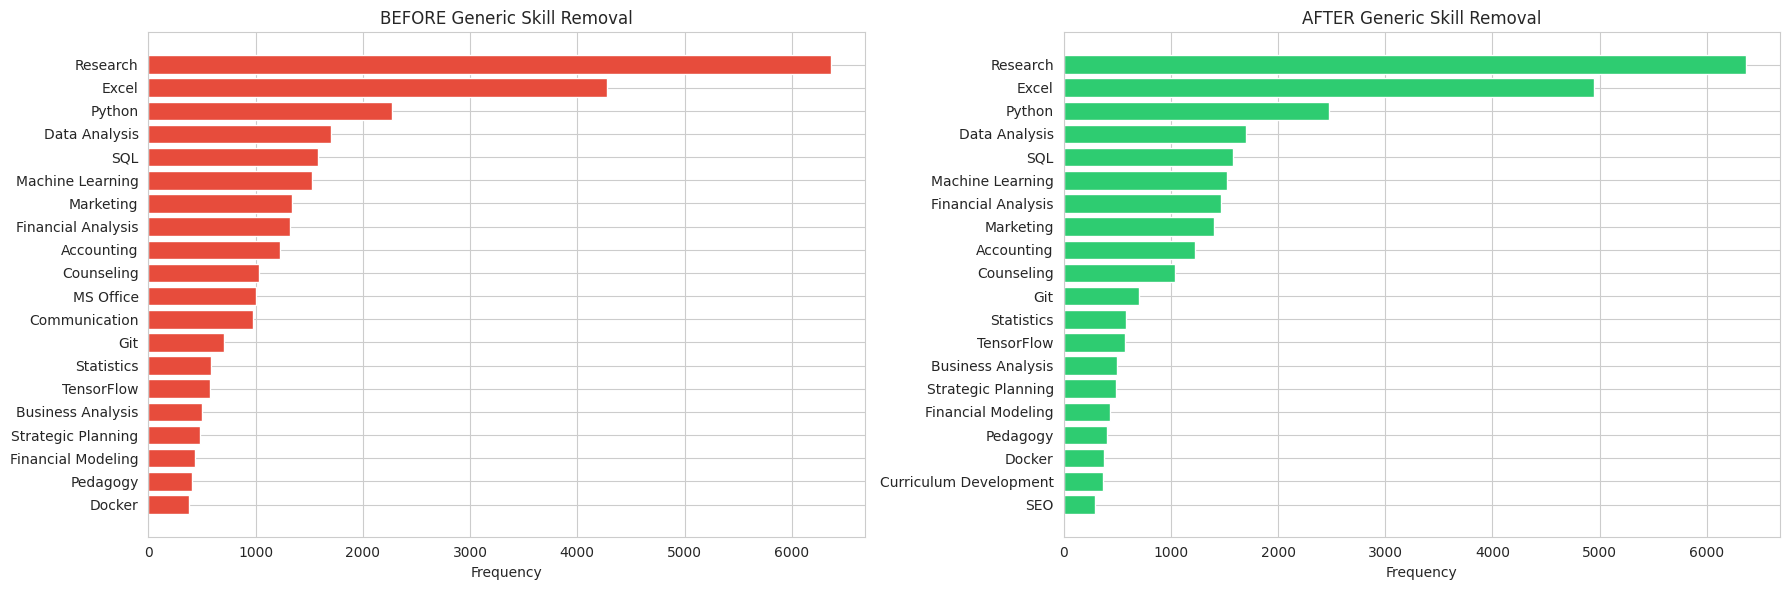


✓ Generic skill removal complete


In [7]:
# STEP 5.5: Remove Generic Skills (No Discriminative Power)

print("=" * 80)
print("STEP 5.5: Removing Generic Skills")
print("=" * 80)

# Define generic skills that appear in 80%+ of profiles
GENERIC_SKILLS_TO_REMOVE = {
    # Universal soft skills (provide no discriminative power)
    'Problem Solving',
    'Communication',
    'Teamwork',
    'Leadership',
    'Creativity',
    'Critical Thinking',
    'Time Management',
    'Organization',
    'Organizational Skills',
    'Attention to Detail',
    'Interpersonal Skills',
    'Adaptability',
    'Work Ethic',
    
    # Generic tools (everyone uses them)
    'MS Office',
    'Microsoft Office',
    'Office Suite',
    'Email',
    'Internet',
    'Computer Skills'
}

# Category-specific default skills (for profiles that end up with < 2 skills)
CATEGORY_DEFAULT_SKILLS = {
    'STEM': ['Python', 'Data Analysis'],
    'Business': ['Marketing', 'Excel'],
    'Finance': ['Financial Analysis', 'Excel'],
    'Health': ['Patient Care', 'Medical Knowledge'],
    'Design': ['Adobe Creative Suite', 'Visual Design'],
    'Legal': ['Legal Research', 'Contract Review'],
    'Education': ['Curriculum Development', 'Pedagogy'],
    'Other': ['Excel', 'Research']
}

# Count before removal
all_skills_before = []
for profile in all_user_profiles:
    all_skills_before.extend(profile['skills'])

skill_counter_before_removal = Counter(all_skills_before)

print(f"\nBEFORE Generic Skill Removal:")
print(f"  Total skill occurrences: {len(all_skills_before):,}")
print(f"  Unique skills: {len(skill_counter_before_removal)}")

print(f"\nGeneric skills to remove: {len(GENERIC_SKILLS_TO_REMOVE)}")
print("  Skills being removed:")
for skill in sorted(GENERIC_SKILLS_TO_REMOVE):
    count = skill_counter_before_removal.get(skill, 0)
    if count > 0:
        print(f"    - {skill:30s}: {count:5d} occurrences")

# Remove generic skills from all profiles
profiles_modified = 0
skills_added_as_defaults = 0

for profile in all_user_profiles:
    # Store original skill count
    original_count = len(profile['skills'])
    
    # Filter out generic skills
    profile['skills'] = [
        s for s in profile['skills'] 
        if s not in GENERIC_SKILLS_TO_REMOVE
    ]
    
    # Check if we removed any skills
    if len(profile['skills']) < original_count:
        profiles_modified += 1
    
    # Ensure minimum 2 skills (add category defaults if needed)
    if len(profile['skills']) < 2:
        category = profile['recommended_category']
        defaults = CATEGORY_DEFAULT_SKILLS.get(category, CATEGORY_DEFAULT_SKILLS['Other'])
        
        # Add defaults that aren't already present
        for default_skill in defaults:
            if default_skill not in profile['skills']:
                profile['skills'].append(default_skill)
                skills_added_as_defaults += 1
                if len(profile['skills']) >= 2:
                    break

# Count after removal
all_skills_after = []
for profile in all_user_profiles:
    all_skills_after.extend(profile['skills'])

skill_counter_after_removal = Counter(all_skills_after)

print(f"\nAFTER Generic Skill Removal:")
print(f"  Total skill occurrences: {len(all_skills_after):,}")
print(f"  Unique skills: {len(skill_counter_after_removal)}")
print(f"  Profiles modified: {profiles_modified:,} ({profiles_modified/len(all_user_profiles)*100:.1f}%)")
print(f"  Default skills added: {skills_added_as_defaults}")

print(f"\nSkills removed:")
print(f"  {len(all_skills_before) - len(all_skills_after):,} skill occurrences deleted")

print(f"\nTop 15 skills after generic removal:")
for skill, count in skill_counter_after_removal.most_common(15):
    print(f"  {skill:35s}: {count:5d}")

print(f"\nDistribution after generic removal:")
counts_after = list(skill_counter_after_removal.values())
if counts_after:
    print(f"  Max: {max(counts_after)}")
    print(f"  Median: {np.median(counts_after):.0f}")
    print(f"  Min: {min(counts_after)}")
    print(f"  Max/Median ratio: {max(counts_after) / np.median(counts_after):.2f}x")

# Visualize the impact
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Before removal
top_20_before = skill_counter_before_removal.most_common(20)
axes[0].barh([s[0][:35] for s in top_20_before], [s[1] for s in top_20_before], color='#e74c3c')
axes[0].set_xlabel('Frequency')
axes[0].set_title('BEFORE Generic Skill Removal')
axes[0].invert_yaxis()

# After removal
top_20_after = skill_counter_after_removal.most_common(20)
axes[1].barh([s[0][:35] for s in top_20_after], [s[1] for s in top_20_after], color='#2ecc71')
axes[1].set_xlabel('Frequency')
axes[1].set_title('AFTER Generic Skill Removal')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(viz_dir / '00_generic_skill_removal.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Generic skill removal complete")
print("=" * 80)

---
## Step 6: PROPER Skill Rebalancing (No User Duplication)

SKILL REBALANCING STRATEGY v5 (BUG-FIXED)
BEFORE:
Total occurrences: 34,170
Unique skills: 128
Median: 14
Max: 6363

Top 10:
  Research                      :  6363
  Excel                         :  4948
  Python                        :  2480
  Data Analysis                 :  1701
  SQL                           :  1582
  Machine Learning              :  1525
  Financial Analysis            :  1473
  Marketing                     :  1404
  Accounting                    :  1228
  Counseling                    :  1036

STEP 1: Remove Rare Skills (< 50 occurrences)
Rare skills to remove: 80

After removal:
Total occurrences: 33,404
Unique skills: 48

STEP 2: DETERMINISTIC Hard Cap at 500
Skills above cap: 14
Research                      :  6371 →  500 (remove 5871)
Excel                         :  4961 →  500 (remove 4461)
Python                        :  2480 →  500 (remove 1980)
Data Analysis                 :  1701 →  500 (remove 1201)
SQL                           :  1582 →  500 (

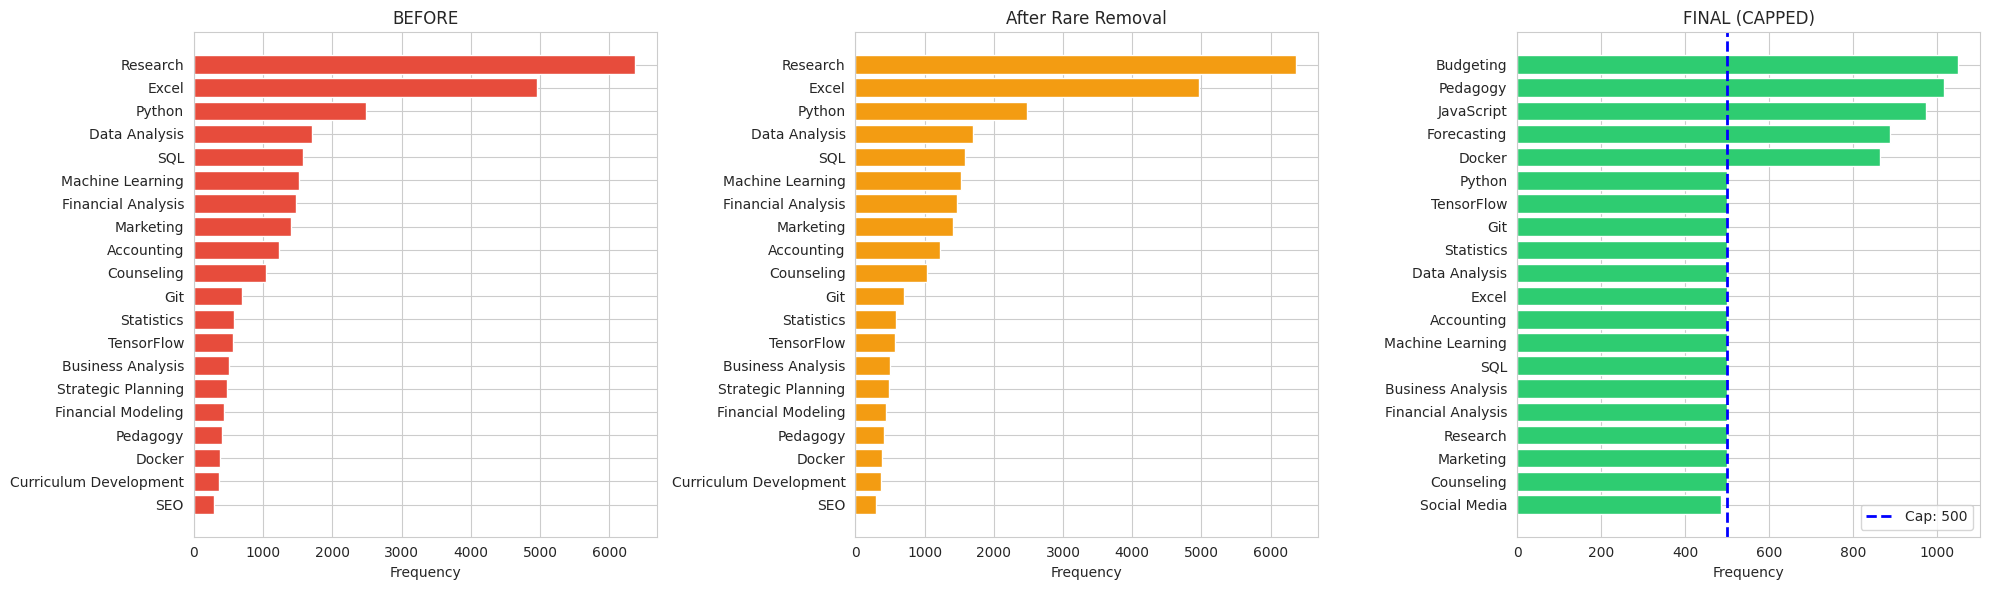


✓ Deterministic skill rebalancing complete (bug-fixed)


In [8]:
# ===============================================================================
# STEP 6: FIXED SKILL REBALANCING (Deterministic + No Re-addition Bug)
# ===============================================================================

print("SKILL REBALANCING STRATEGY v5 (BUG-FIXED)")
print("=" * 80)

# Collect initial skills
all_skills_raw = []
for profile in all_user_profiles:
    all_skills_raw.extend(profile['skills'])

skill_counter_before = Counter(all_skills_raw)

print("BEFORE:")
print(f"Total occurrences: {len(all_skills_raw):,}")
print(f"Unique skills: {len(skill_counter_before)}")
print(f"Median: {np.median(list(skill_counter_before.values())):.0f}")
print(f"Max: {skill_counter_before.most_common(1)[0][1]}")
print(f"\nTop 10:")
for skill, count in skill_counter_before.most_common(10):
    print(f"  {skill:30s}: {count:5d}")

# ===== STEP 1: Remove rare skills (< 50) =====
print("\n" + "=" * 80)
print("STEP 1: Remove Rare Skills (< 50 occurrences)")
print("=" * 80)

RARE_THRESHOLD = 50
rare_skills = {skill for skill, count in skill_counter_before.items() if count < RARE_THRESHOLD}
print(f"Rare skills to remove: {len(rare_skills)}")

for profile in all_user_profiles:
    profile['skills'] = [s for s in profile['skills'] if s not in rare_skills]
    if len(profile['skills']) < 2:
        # Simple defaults without risk of over-capping
        if 'Excel' not in profile['skills']:
            profile['skills'].append('Excel')
        if len(profile['skills']) < 2 and 'Research' not in profile['skills']:
            profile['skills'].append('Research')

all_skills_after_removal = []
for profile in all_user_profiles:
    all_skills_after_removal.extend(profile['skills'])

skill_counter_after_removal = Counter(all_skills_after_removal)
print(f"\nAfter removal:")
print(f"Total occurrences: {len(all_skills_after_removal):,}")
print(f"Unique skills: {len(skill_counter_after_removal)}")

# ===== STEP 2: DETERMINISTIC Hard Cap at 500 =====
print("\n" + "=" * 80)
print("STEP 2: DETERMINISTIC Hard Cap at 500")
print("=" * 80)

HARD_CAP = 500

# Build skill-to-users index
skill_to_users = {}
for idx, profile in enumerate(all_user_profiles):
    for skill in profile['skills']:
        if skill not in skill_to_users:
            skill_to_users[skill] = []
        skill_to_users[skill].append(idx)

# Track which skills we're capping (to avoid re-adding them later)
skills_being_capped = set()

# For each overcapped skill, randomly remove from users
skills_to_cap = {skill: count for skill, count in skill_counter_after_removal.items() if count > HARD_CAP}

print(f"Skills above cap: {len(skills_to_cap)}")
for skill, count in sorted(skills_to_cap.items(), key=lambda x: -x[1]):
    print(f"{skill:30s}: {count:5d} → {HARD_CAP:4d} (remove {count - HARD_CAP})")
    skills_being_capped.add(skill)

for skill, current_count in skills_to_cap.items():
    to_remove = current_count - HARD_CAP
    users_with_skill = skill_to_users[skill].copy()
    random.shuffle(users_with_skill)
    users_to_modify = users_with_skill[:to_remove]
    
    for user_idx in users_to_modify:
        profile = all_user_profiles[user_idx]
        if skill in profile['skills']:
            profile['skills'].remove(skill)

# ===== STEP 3: FIX MINIMUM SKILLS (Without re-adding capped skills) =====
print("\n" + "=" * 80)
print("STEP 3: Ensure Minimum 2 Skills (Avoiding Capped Skills)")
print("=" * 80)

# Non-capped skills we can safely use as defaults
SAFE_DEFAULT_SKILLS = {
    'STEM': ['Git', 'JavaScript', 'Docker'],
    'Business': ['Social Media', 'Content Creation', 'SEO'],
    'Finance': ['Excel', 'Budgeting', 'Forecasting'],
    'Education': ['Pedagogy', 'Lesson Planning'],
    'Health': ['Patient Care', 'Medical Knowledge'],
    'Design': ['Visual Design', 'Adobe Creative Suite'],
    'Legal': ['Legal Research', 'Contract Review'],
    'Other': ['Excel', 'Git']
}

profiles_fixed = 0
for profile in all_user_profiles:
    if len(profile['skills']) < 2:
        category = profile['recommended_category']
        defaults = SAFE_DEFAULT_SKILLS.get(category, SAFE_DEFAULT_SKILLS['Other'])
        
        for default_skill in defaults:
            # Only add if:
            # 1. Not already in profile
            # 2. Not a skill we just capped
            if default_skill not in profile['skills'] and default_skill not in skills_being_capped:
                profile['skills'].append(default_skill)
                profiles_fixed += 1
                if len(profile['skills']) >= 2:
                    break

print(f"Profiles with added defaults: {profiles_fixed}")

# Final count
all_skills_final = []
for profile in all_user_profiles:
    all_skills_final.extend(profile['skills'])

skill_counter_final = Counter(all_skills_final)

print("\n" + "=" * 80)
print("AFTER REBALANCING")
print("=" * 80)
print(f"Total occurrences: {len(all_skills_final):,}")
print(f"Unique skills: {len(skill_counter_final)}")
print(f"\nTop 10:")
for skill, count in skill_counter_final.most_common(10):
    print(f"  {skill:30s}: {count:5d}")

print(f"\nBottom 10:")
for skill, count in sorted(skill_counter_final.items(), key=lambda x: x[1])[:10]:
    print(f"  {skill:30s}: {count:5d}")

counts = list(skill_counter_final.values())
print(f"\nDistribution:")
print(f"  Max: {max(counts)}")
print(f"  Median: {np.median(counts):.0f}")
print(f"  Min: {min(counts)}")
print(f"  Max/Median ratio: {max(counts) / np.median(counts):.2f}x")

# Verify cap worked
over_cap = {skill: count for skill, count in skill_counter_final.items() if count > HARD_CAP}
if over_cap:
    print(f"\n⚠️  WARNING: {len(over_cap)} skills still over cap:")
    for skill, count in over_cap.items():
        print(f"  {skill}: {count}")
else:
    print(f"\n✅ SUCCESS: All skills at or below {HARD_CAP}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

top_20_before = skill_counter_before.most_common(20)
axes[0].barh([s[0][:30] for s in top_20_before], [s[1] for s in top_20_before], color='#e74c3c')
axes[0].set_xlabel('Frequency')
axes[0].set_title('BEFORE')
axes[0].invert_yaxis()

top_20_removal = skill_counter_after_removal.most_common(20)
axes[1].barh([s[0][:30] for s in top_20_removal], [s[1] for s in top_20_removal], color='#f39c12')
axes[1].set_xlabel('Frequency')
axes[1].set_title('After Rare Removal')
axes[1].invert_yaxis()

top_20_final = skill_counter_final.most_common(20)
axes[2].barh([s[0][:30] for s in top_20_final], [s[1] for s in top_20_final], color='#2ecc71')
axes[2].set_xlabel('Frequency')
axes[2].set_title('FINAL (CAPPED)')
axes[2].invert_yaxis()
axes[2].axvline(HARD_CAP, color='blue', linestyle='--', linewidth=2, label=f'Cap: {HARD_CAP}')
axes[2].legend()

plt.tight_layout()
plt.savefig(viz_dir / '01_skill_rebalancing_v5_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Deterministic skill rebalancing complete (bug-fixed)")

---
## Step 7: Build Simulation Catalog with Balanced Categories

BUILDING BALANCED SIMULATION CATALOG
Total unique careers: 110

Careers per category:
recommended_category
Other        40
STEM         33
Business      9
Finance       9
Education     7
Health        6
Design        5
Legal         1
Name: recommended_career, dtype: int64

✓ Created 64 simulations

Category Distribution:
simulation_categoria
STEM         20
Business      9
Finance       9
Other         7
Education     7
Health        6
Design        5
Legal         1
Name: count, dtype: int64

'Other' percentage: 10.9%

Difficulty Distribution:
simulation_nivel_dificultad
Advanced              18
Beginner              14
Lower-Intermediate    14
Upper-Intermediate    11
Expert                 7
Name: count, dtype: int64


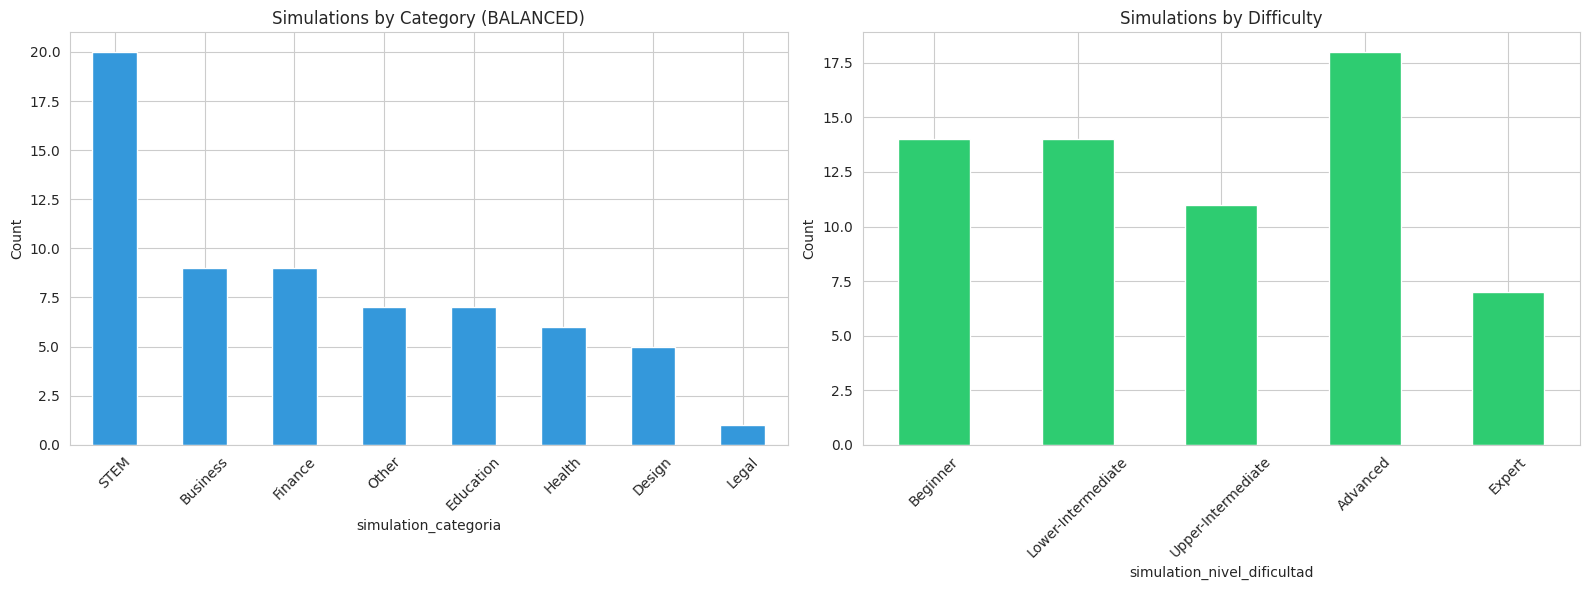


✓ Balanced simulation catalog created


In [9]:
print("BUILDING BALANCED SIMULATION CATALOG")
print("="*80)

# Extract unique careers
df_all_profiles = pd.DataFrame(all_user_profiles)
all_careers = df_all_profiles['recommended_career'].unique()
print(f"Total unique careers: {len(all_careers)}")

# Check category distribution
career_categories = df_all_profiles.groupby('recommended_category')['recommended_career'].nunique()
print("\nCareers per category:")
print(career_categories.sort_values(ascending=False))

# Balance: Ensure 10-20 simulations per major category
TARGET_SIMS_PER_CATEGORY = {'STEM': 20, 'Business': 15, 'Finance': 12, 'Health': 10, 
                             'Design': 10, 'Legal': 8, 'Education': 8, 'Other': 7}

simulations = []
category_counts = Counter()

# Difficulty mapping
DIFFICULTY_DURATION_MAP = {
    'Beginner': (3, 5),
    'Lower-Intermediate': (5, 8),
    'Upper-Intermediate': (8, 12),
    'Advanced': (12, 16),
    'Expert': (16, 20)
}

CATEGORY_DIFFICULTY_PREFS = {
    'STEM': {'Beginner': 0.10, 'Lower-Intermediate': 0.20, 'Upper-Intermediate': 0.30, 'Advanced': 0.25, 'Expert': 0.15},
    'Business': {'Beginner': 0.20, 'Lower-Intermediate': 0.30, 'Upper-Intermediate': 0.25, 'Advanced': 0.20, 'Expert': 0.05},
    'Finance': {'Beginner': 0.10, 'Lower-Intermediate': 0.20, 'Upper-Intermediate': 0.25, 'Advanced': 0.30, 'Expert': 0.15},
    'Health': {'Beginner': 0.15, 'Lower-Intermediate': 0.25, 'Upper-Intermediate': 0.30, 'Advanced': 0.25, 'Expert': 0.05},
    'Design': {'Beginner': 0.25, 'Lower-Intermediate': 0.30, 'Upper-Intermediate': 0.25, 'Advanced': 0.15, 'Expert': 0.05},
    'Legal': {'Beginner': 0.05, 'Lower-Intermediate': 0.15, 'Upper-Intermediate': 0.25, 'Advanced': 0.35, 'Expert': 0.20},
    'Education': {'Beginner': 0.30, 'Lower-Intermediate': 0.30, 'Upper-Intermediate': 0.20, 'Advanced': 0.15, 'Expert': 0.05},
    'Other': {'Beginner': 0.20, 'Lower-Intermediate': 0.25, 'Upper-Intermediate': 0.25, 'Advanced': 0.20, 'Expert': 0.10}
}

# Create simulations with category balancing
for career in all_careers:
    category = map_career_to_category(career)
    
    # Skip if category is full
    if category_counts[category] >= TARGET_SIMS_PER_CATEGORY.get(category, 10):
        continue
    
    prefs = CATEGORY_DIFFICULTY_PREFS.get(category, CATEGORY_DIFFICULTY_PREFS['Other'])
    difficulty = np.random.choice(list(prefs.keys()), p=list(prefs.values()))
    
    min_dur, max_dur = DIFFICULTY_DURATION_MAP[difficulty]
    duration = round(random.uniform(min_dur, max_dur), 1)
    
    industria = CATEGORY_TO_INDUSTRY.get(category, 'General')
    required_skills = infer_skills_for_career(career, existing_skills=[])
    
    simulations.append({
        'simulation_id': f'sim_{career.lower().replace(" ", "_")}',
        'simulation_title': f'{career} Virtual Experience',
        'simulation_categoria': category,
        'simulation_nivel_dificultad': difficulty,
        'simulation_duracion_horas': duration,
        'simulation_industria': industria,
        'simulation_required_skills': required_skills,
        'base_career': career
    })
    
    category_counts[category] += 1

df_simulations = pd.DataFrame(simulations)

print(f"\n✓ Created {len(simulations)} simulations")
print("\nCategory Distribution:")
print(df_simulations['simulation_categoria'].value_counts())
print(f"\n'Other' percentage: {(df_simulations['simulation_categoria'] == 'Other').mean() * 100:.1f}%")

print("\nDifficulty Distribution:")
print(df_simulations['simulation_nivel_dificultad'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_simulations['simulation_categoria'].value_counts().plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Simulations by Category (BALANCED)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

difficulty_order = ['Beginner', 'Lower-Intermediate', 'Upper-Intermediate', 'Advanced', 'Expert']
diff_counts = df_simulations['simulation_nivel_dificultad'].value_counts().reindex(difficulty_order, fill_value=0)
diff_counts.plot(kind='bar', ax=axes[1], color='#2ecc71')
axes[1].set_title('Simulations by Difficulty')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(viz_dir / '02_simulation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Balanced simulation catalog created")

In [10]:
# ===============================================================================
# STEP 7.5: Clean Generic Skills from Simulations
# INSERT THIS NEW CELL AFTER Step 7 (Build Simulation Catalog)
# ===============================================================================

print("="*80)
print("STEP 7.5: Cleaning Generic Skills from Simulations")
print("="*80)

# Generic skills to remove from simulations
GENERIC_TO_REMOVE = {
    'Problem Solving', 'Communication', 'Teamwork', 
    'Leadership', 'Creativity', 'Critical Thinking',
    'Time Management', 'Organization', 'Adaptability'
}

# Category-specific replacement skills
CATEGORY_REPLACEMENTS = {
    'STEM': ['Python', 'Data Analysis', 'Git'],
    'Business': ['Marketing', 'Excel', 'Project Management'],
    'Finance': ['Financial Analysis', 'Accounting', 'Excel'],
    'Health': ['Patient Care', 'Medical Knowledge', 'Clinical Assessment'],
    'Design': ['Visual Design', 'Adobe Creative Suite', 'Figma'],
    'Education': ['Pedagogy', 'Curriculum Development', 'Lesson Planning'],
    'Legal': ['Legal Research', 'Contract Review', 'Legal Writing'],
    'Other': ['Research', 'Excel', 'Data Analysis']
}

import ast

sims_cleaned = 0
skills_removed = 0
skills_added = 0

for idx, row in df_simulations.iterrows():
    try:
        # Parse skills (handle both string and list formats)
        if isinstance(row['simulation_required_skills'], str):
            skills = ast.literal_eval(row['simulation_required_skills'])
        else:
            skills = row['simulation_required_skills']
        
        original_count = len(skills)
        
        # Remove generic skills
        cleaned = [s for s in skills if s not in GENERIC_TO_REMOVE]
        skills_removed += (original_count - len(cleaned))
        
        # If empty or too few after removal, add category-specific skills
        if len(cleaned) < 3:
            category = row['simulation_categoria']
            replacements = CATEGORY_REPLACEMENTS.get(category, CATEGORY_REPLACEMENTS['Other'])
            
            for replacement in replacements:
                if replacement not in cleaned:
                    cleaned.append(replacement)
                    skills_added += 1
                    if len(cleaned) >= 3:
                        break
        
        # Update the row
        df_simulations.at[idx, 'simulation_required_skills'] = str(cleaned)
        
        if original_count != len(cleaned):
            sims_cleaned += 1
            
    except Exception as e:
        print(f"  Warning: Could not clean simulation {idx}: {e}")
        continue

print(f"\nCleaning Results:")
print(f"  Simulations modified: {sims_cleaned}/{len(df_simulations)}")
print(f"  Generic skills removed: {skills_removed}")
print(f"  Specific skills added: {skills_added}")

# Verify - check what skills are now in simulations
all_sim_skills_after = []
for skills_str in df_simulations['simulation_required_skills']:
    try:
        skills = ast.literal_eval(skills_str)
        all_sim_skills_after.extend(skills)
    except:
        pass

sim_skill_counter_after = Counter(all_sim_skills_after)

print(f"\nTop 10 simulation skills after cleaning:")
for skill, count in sim_skill_counter_after.most_common(10):
    print(f"  {skill:30s}: {count:3d} simulations")

# Check if any generic skills remain
remaining_generic = [skill for skill in GENERIC_TO_REMOVE if skill in sim_skill_counter_after]
if remaining_generic:
    print(f"\n⚠️  Warning: {len(remaining_generic)} generic skills still present:")
    for skill in remaining_generic:
        print(f"  {skill}: {sim_skill_counter_after[skill]} simulations")
else:
    print(f"\n✅ Success: All generic skills removed from simulations")

print("\n✓ Simulation skills cleaned")

STEP 7.5: Cleaning Generic Skills from Simulations

Cleaning Results:
  Simulations modified: 42/64
  Generic skills removed: 0
  Specific skills added: 57

Top 10 simulation skills after cleaning:
  Research                      :  46 simulations
  Excel                         :  35 simulations
  Python                        :  18 simulations
  Data Analysis                 :  15 simulations
  Financial Analysis            :   9 simulations
  SQL                           :   7 simulations
  Marketing                     :   7 simulations
  Pedagogy                      :   7 simulations
  Patient Care                  :   6 simulations
  Statistics                    :   4 simulations

✅ Success: All generic skills removed from simulations

✓ Simulation skills cleaned


---
## Step 8-12: Generate Training Data, Encode, Save

In [11]:
# Build skills catalog
all_skills_final = []
for profile in all_user_profiles:
    all_skills_final.extend(profile['skills'])

skill_counter_final = Counter(all_skills_final)

skills_catalog = []
for skill_id, (skill_name, count) in enumerate(skill_counter_final.most_common(), start=1):
    skills_catalog.append({
        'skill_id': skill_id,
        'skill_name': skill_name,
        'frequency': count,
        'slug': re.sub(r'[^a-z0-9]+', '-', skill_name.lower()).strip('-')
    })

df_skills_catalog = pd.DataFrame(skills_catalog)
skill_to_id = {row['skill_name']: row['skill_id'] for _, row in df_skills_catalog.iterrows()}

print(f"✓ Skills catalog: {len(df_skills_catalog)} unique skills")
print(f"\nFrequency stats: Min={df_skills_catalog['frequency'].min()}, "
      f"Median={df_skills_catalog['frequency'].median():.0f}, Max={df_skills_catalog['frequency'].max()}")

# Generate training samples
print(f"\nGenerating training samples...")
training_samples = []

for user in all_user_profiles:
    positive_sim = next((s for s in simulations if s['base_career'] == user['recommended_career']), None)
    if positive_sim is None:
        continue
    
    user_skill_ids = [skill_to_id[s] for s in user['skills'] if s in skill_to_id]
    sim_skill_ids = [skill_to_id[s] for s in positive_sim['simulation_required_skills'] if s in skill_to_id]
    
    skill_overlap = len(set(user_skill_ids) & set(sim_skill_ids))
    max_possible = max(len(user_skill_ids), len(sim_skill_ids), 1)
    skill_match_score = skill_overlap / max_possible
    
    base_score = user['base_engagement_score']
    engagement_prob = (base_score * 0.7) + (skill_match_score * 0.3)
    engagement_prob = np.clip(engagement_prob, 0.0, 1.0)
    label = 1 if engagement_prob > 0.5 else 0
    
    training_samples.append({
        'user_id': user['user_id'],
        'user_skill_ids': user_skill_ids,
        'education_level': user['education_level'],
        'field_of_study': user['field_of_study'],
        'analytical_score': user['analytical_score'],
        'creative_score': user['creative_score'],
        'social_score': user['social_score'],
        'linguistic_score': user['linguistic_score'],
        'hands_on_score': user['hands_on_score'],
        'simulation_id': positive_sim['simulation_id'],
        'simulation_categoria': positive_sim['simulation_categoria'],
        'simulation_nivel_dificultad': positive_sim['simulation_nivel_dificultad'],
        'simulation_duracion_horas': positive_sim['simulation_duracion_horas'],
        'simulation_industria': positive_sim['simulation_industria'],
        'simulation_skill_ids': sim_skill_ids,
        'label': label,
        'engagement_probability': engagement_prob,
        'source_dataset': user['source_dataset'],
        'sample_type': 'positive'
    })
    
    # Negative samples
    different_category_sims = [s for s in simulations if s['simulation_categoria'] != user['recommended_category']]
    if len(different_category_sims) >= 2:
        negative_sims = random.sample(different_category_sims, 2)
        for neg_sim in negative_sims:
            neg_skill_ids = [skill_to_id[s] for s in neg_sim['simulation_required_skills'] if s in skill_to_id]
            neg_engagement_prob = np.random.uniform(0.1, 0.4)
            training_samples.append({
                'user_id': user['user_id'],
                'user_skill_ids': user_skill_ids,
                'education_level': user['education_level'],
                'field_of_study': user['field_of_study'],
                'analytical_score': user['analytical_score'],
                'creative_score': user['creative_score'],
                'social_score': user['social_score'],
                'linguistic_score': user['linguistic_score'],
                'hands_on_score': user['hands_on_score'],
                'simulation_id': neg_sim['simulation_id'],
                'simulation_categoria': neg_sim['simulation_categoria'],
                'simulation_nivel_dificultad': neg_sim['simulation_nivel_dificultad'],
                'simulation_duracion_horas': neg_sim['simulation_duracion_horas'],
                'simulation_industria': neg_sim['simulation_industria'],
                'simulation_skill_ids': neg_skill_ids,
                'label': 0,
                'engagement_probability': neg_engagement_prob,
                'source_dataset': user['source_dataset'],
                'sample_type': 'negative'
            })

df_training = pd.DataFrame(training_samples)
print(f"✓ Generated {len(df_training):,} training samples")
print(f"\nLabel distribution:")
print(df_training['label'].value_counts())
print(f"Positive rate: {df_training['label'].mean()*100:.2f}%")

# Encode categoricals
encoders = {}
categorical_features = ['education_level', 'field_of_study', 'simulation_categoria', 
                       'simulation_nivel_dificultad', 'simulation_industria']

df_encoded = df_training.copy()
for feature in categorical_features:
    le = LabelEncoder()
    df_encoded[f'{feature}_encoded'] = le.fit_transform(df_encoded[feature])
    encoders[feature] = le

print("\n✓ Categorical features encoded")

# Create skill vectors
num_skills = len(df_skills_catalog)
user_skill_vectors = []
sim_skill_vectors = []

for _, row in df_encoded.iterrows():
    user_vec = np.zeros(num_skills, dtype=np.int8)
    for skill_id in row['user_skill_ids']:
        if 1 <= skill_id <= num_skills:
            user_vec[skill_id - 1] = 1
    user_skill_vectors.append(user_vec)
    
    sim_vec = np.zeros(num_skills, dtype=np.int8)
    for skill_id in row['simulation_skill_ids']:
        if 1 <= skill_id <= num_skills:
            sim_vec[skill_id - 1] = 1
    sim_skill_vectors.append(sim_vec)

print(f"\n✓ Skill vectors created ({num_skills} dimensions)")

# Save
df_save = df_encoded.drop(columns=['user_skill_ids', 'simulation_skill_ids'])
df_save.to_csv(output_dir / 'unified_training_dataset_v3.csv', index=False)

user_skill_matrix = np.vstack(user_skill_vectors)
sim_skill_matrix = np.vstack(sim_skill_vectors)
np.save(output_dir / 'user_skill_vectors.npy', user_skill_matrix)
np.save(output_dir / 'simulation_skill_vectors.npy', sim_skill_matrix)

df_skills_catalog.to_csv(output_dir / 'skills_catalog.csv', index=False)
df_simulations.to_csv(output_dir / 'simulation_catalog.csv', index=False)

import pickle
with open(output_dir / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

metadata = {
    'total_samples': len(df_encoded),
    'positive_samples': int(df_encoded['label'].sum()),
    'negative_samples': int((1 - df_encoded['label']).sum()),
    'positive_rate': float(df_encoded['label'].mean()),
    'num_users': len(all_user_profiles),
    'num_simulations': len(simulations),
    'num_skills': num_skills,
    'difficulty_levels': ['Beginner', 'Lower-Intermediate', 'Upper-Intermediate', 'Advanced', 'Expert'],
    'skill_distribution': {
        'max': int(df_skills_catalog['frequency'].max()),
        'median': int(df_skills_catalog['frequency'].median()),
        'min': int(df_skills_catalog['frequency'].min())
    }
}

with open(output_dir / 'dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n" + "="*80)
print("FINAL DATASET SUMMARY")
print("="*80)
print(f"Total training samples: {len(df_encoded):,}")
print(f"Unique users: {len(all_user_profiles):,}")
print(f"Unique simulations: {len(simulations)}")
print(f"Unique skills: {num_skills}")
print(f"\nPositive rate: {metadata['positive_rate']*100:.2f}%")
print(f"\nSkill distribution (BALANCED):")
print(f"  Max: {metadata['skill_distribution']['max']}")
print(f"  Median: {metadata['skill_distribution']['median']}")
print(f"  Min: {metadata['skill_distribution']['min']}")
print(f"  Max/Median ratio: {metadata['skill_distribution']['max'] / metadata['skill_distribution']['median']:.2f}x")
print(f"\nDifficulty levels: {', '.join(metadata['difficulty_levels'])}")
print(f"\n✅ ALL FILES SAVED TO: {output_dir}")
print(f"📊 VISUALIZATIONS SAVED TO: {viz_dir}")

✓ Skills catalog: 52 unique skills

Frequency stats: Min=50, Median=280, Max=1049

Generating training samples...
✓ Generated 18,501 training samples

Label distribution:
label
0    13630
1     4871
Name: count, dtype: int64
Positive rate: 26.33%

✓ Categorical features encoded

✓ Skill vectors created (52 dimensions)

FINAL DATASET SUMMARY
Total training samples: 18,501
Unique users: 8,800
Unique simulations: 64
Unique skills: 52

Positive rate: 26.33%

Skill distribution (BALANCED):
  Max: 1049
  Median: 280
  Min: 50
  Max/Median ratio: 3.75x

Difficulty levels: Beginner, Lower-Intermediate, Upper-Intermediate, Advanced, Expert

✅ ALL FILES SAVED TO: /workspace/data/processed
📊 VISUALIZATIONS SAVED TO: /workspace/data/visualizations
